# NCAA Pitch Type Model EDA

### By: Mojisoluwa (Jiso) Awe


This is the exploratory data analysis and model evaluation I did at the start of the project. My intent for this project was intended to create a model that can accurately predict pitch types, but specifically tailored to college players. College players generally have less defined pitch shapes, compared to most professional baseball players.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
from sklearn.metrics import classification_report,confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

In [3]:
data = pd.read_csv('NCAA_Pitch.csv')
#data.head(5)

In [4]:
#list(data.columns)

['id',
 'PitchNo',
 'Date',
 'Time',
 'PAofInning',
 'PitchofPA',
 'PitcherId',
 'PitcherThrows',
 'PitcherTeam',
 'BatterId',
 'BatterSide',
 'BatterTeam',
 'PitcherSet',
 'Inning',
 'TopOrBottom',
 'Outs',
 'Balls',
 'Strikes',
 'TaggedPitchType',
 'AutoPitchType',
 'PitchCall',
 'KorBB',
 'TaggedHitType',
 'PlayResult',
 'OutsOnPlay',
 'RunsScored',
 'Notes',
 'RelSpeed',
 'VertRelAngle',
 'HorzRelAngle',
 'SpinRate',
 'SpinAxis',
 'Tilt',
 'RelHeight',
 'RelSide',
 'Extension',
 'VertBreak',
 'InducedVertBreak',
 'HorzBreak',
 'PlateLocHeight',
 'PlateLocSide',
 'ZoneSpeed',
 'VertApprAngle',
 'HorzApprAngle',
 'ZoneTime',
 'ExitSpeed',
 'Angle',
 'Direction',
 'HitSpinRate',
 'PositionAt110X',
 'PositionAt110Y',
 'PositionAt110Z',
 'Distance',
 'LastTrackedDistance',
 'Bearing',
 'HangTime',
 'pfxx',
 'pfxz',
 'x0',
 'y0',
 'z0',
 'vx0',
 'vy0',
 'vz0',
 'ax0',
 'ay0',
 'az0',
 'HomeTeam',
 'AwayTeam',
 'Stadium',
 'Level',
 'League',
 'TrackmanGameID',
 'PitchUID',
 'EffectiveVel

For the in depth descriptions of each of these metrics visit Trackman's metric glossary: https://support.trackmanbaseball.com/hc/en-us/articles/5089413493787-V3-FAQs-Radar-Measurement-Glossary-Of-Terms

# Exploratory Data Analysis

In [19]:
data['TaggedPitchType'].value_counts()

TaggedPitchType
Fastball       23038
Slider          5727
ChangeUp        3515
Undefined       1916
Curveball       1845
Sinker           471
Cutter           462
Splitter          45
Other             36
Knuckleball        4
Name: count, dtype: int64

# this might be bs reread
Generally, when one is referring to the "fastball", they are talking about the four-seam fastball. The sinker is a two-seam fastball and at the collegiate level, many people just refer to sinkers as fastballs. The distinction between the two pitch types comes from the way that the pitcher orients the seams of the ball when throwing it. The sinker tends to have more horizontal movement / armside movement (run). Opposed to the traditional four-seam fastball which has more vertical movement and is more resistant to "dropping" (ride).

# bad idea pls rewrite lol
For the purposes of this project, seeing as I'm trying to predict college pitch types, I'll be categorizing sinkers as fastballs. Additionally, due to the data imbalance for certain pitch types (Other, Splittler, Undefined, and Knuckleball), these pitch types will be excluded from the dataset to ensure more reliable model performance. 

In [57]:
desired_pitch_types = ['Fastball', 'Slider', 'Changeup', 'Curveball', 'Sinker', 'Cutter']
df_pt = data[data['TaggedPitchType'].isin(desired_pitch_types)]

In [63]:
df_pt['RelSpeed'].describe()

count    31532.000000
mean        86.720153
std          5.835516
min         65.013400
25%         83.028950
50%         88.226450
75%         90.986850
max         98.913600
Name: RelSpeed, dtype: float64

<Axes: xlabel='RelSpeed'>

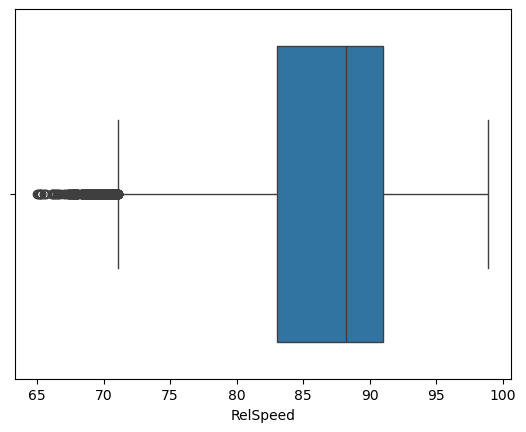

In [61]:
sns.boxplot(x = df_pt['RelSpeed'])

In [59]:
df_pt = df_pt[df_pt['RelSpeed'] > 65]

### Movement Plots

I've created two seperate movement plots based on pitcher handedness. Due to the difference in release side (the hand throwing the pitch), the general movement profiles between lefties and righties are flipped. This applies to number of measurable variables such as horizontal break, horizontal release angle, and horizontal approach angle. When creating the model, these differences will be important to account for when feature engineering.

Generally, velocity, horizontal and induced vertical break, spin rate, tilt, and launch angles are key variables used to identify pitch types when looking at data. For those unfamilar with TrackMan's system, the person tagging the pitches is usually in a secondary location, off the field so the data is their primary source of determining pitch type, especially if they don't have access to live video.

During my time with the San Francisco Giants and the Philadelphia Phillies, I leveraged a similar type of visualization to analyze pitchers shapes, which was especially useful when creating player development plans, transfer reports for players moving through the minor league system, and scouting reports on opposing players. 

In [30]:
lefties = df_pt[df_pt['PitcherThrows'] == 'Left']
#lefties.head()
righties = df_pt[df_pt['PitcherThrows'] == 'Right']

<Axes: xlabel='HorzBreak', ylabel='InducedVertBreak'>

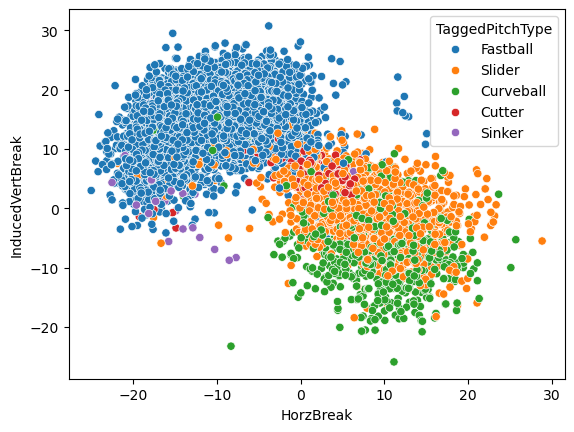

In [32]:
sns.scatterplot(data = lefties, x = 'HorzBreak', y = 'InducedVertBreak', hue = 'TaggedPitchType')

<Axes: xlabel='HorzBreak', ylabel='InducedVertBreak'>

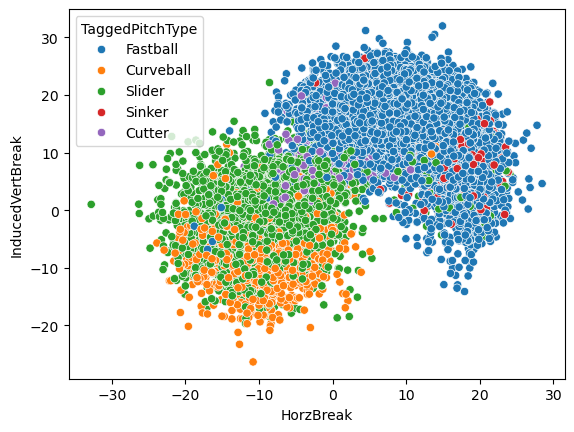

In [34]:
sns.scatterplot(data = righties, x = 'HorzBreak', y = 'InducedVertBreak', hue = 'TaggedPitchType')

## Preprocessing

In [67]:
df_pt['vx0'].describe()

count    31532.000000
mean         2.102137
std          5.321677
min        -14.924200
25%         -2.549993
50%          3.642680
75%          6.049777
max         15.312700
Name: vx0, dtype: float64

In [87]:
list(df_pt.columns)

['id',
 'PitchNo',
 'Date',
 'Time',
 'PAofInning',
 'PitchofPA',
 'PitcherId',
 'PitcherThrows',
 'PitcherTeam',
 'BatterId',
 'BatterSide',
 'BatterTeam',
 'PitcherSet',
 'Inning',
 'TopOrBottom',
 'Outs',
 'Balls',
 'Strikes',
 'TaggedPitchType',
 'AutoPitchType',
 'PitchCall',
 'KorBB',
 'TaggedHitType',
 'PlayResult',
 'OutsOnPlay',
 'RunsScored',
 'Notes',
 'RelSpeed',
 'VertRelAngle',
 'HorzRelAngle',
 'SpinRate',
 'SpinAxis',
 'Tilt',
 'RelHeight',
 'RelSide',
 'Extension',
 'VertBreak',
 'InducedVertBreak',
 'HorzBreak',
 'PlateLocHeight',
 'PlateLocSide',
 'ZoneSpeed',
 'VertApprAngle',
 'HorzApprAngle',
 'ZoneTime',
 'ExitSpeed',
 'Angle',
 'Direction',
 'HitSpinRate',
 'PositionAt110X',
 'PositionAt110Y',
 'PositionAt110Z',
 'Distance',
 'LastTrackedDistance',
 'Bearing',
 'HangTime',
 'pfxx',
 'pfxz',
 'x0',
 'y0',
 'z0',
 'x_velo',
 'y_velo',
 'z_velo',
 'x_acceleration',
 'y_acceleration',
 'z_acceleration',
 'HomeTeam',
 'AwayTeam',
 'Stadium',
 'Level',
 'League',
 'Tr

In [83]:
df_pt = df_pt.rename(
    columns =
    {
        'vx0' : 'x_velo',
        'vy0' : 'y_velo',
        'vz0' : 'z_velo',
        'ax0' : 'x_acceleration',
        'ay0' : 'y_acceleration',
        'az0' : 'z_acceleration'
        # 'PitchTrajectoryXc0' : '', 'PitchTrajectoryXc1', 'PitchTrajectoryXc2',
        #   'PitchTrajectoryYc0', 'PitchTrajectoryYc1', 'PitchTrajectoryYc2', 'PitchTrajectoryZc0',
        # 'PitchTrajectoryZc1','PitchTrajectoryZc2'
    }
)

In [89]:
#Updating the data to include only the pitching related columns
pitch_characteristics = ['PitcherThrows', 'RelSpeed', 'VertRelAngle', 'HorzRelAngle', 'SpinRate', 'SpinAxis',
            'RelHeight', 'RelSide', 'Extension', 'VertBreak', 'InducedVertBreak', 'HorzBreak', 'ZoneSpeed',
           'VertApprAngle', 'HorzApprAngle', 'x_velo', 'y_velo', 'z_velo', 'x_acceleration', 'y_acceleration', 'z_acceleration',
            # 'PitchTrajectoryXc0','PitchTrajectoryXc1', 'PitchTrajectoryXc2',
            #'PitchTrajectoryYc0', 'PitchTrajectoryYc1', 'PitchTrajectoryYc2', 'PitchTrajectoryZc0',
            #'PitchTrajectoryZc1','PitchTrajectoryZc2', 
            'TaggedPitchType', 'Tilt']

updated_df = df_pt[pitch_characteristics]


In [91]:
updated_df.head(5)

,PitcherThrows,RelSpeed,VertRelAngle,HorzRelAngle,SpinRate,SpinAxis,RelHeight,RelSide,Extension,VertBreak,...,VertApprAngle,HorzApprAngle,x_velo,y_velo,z_velo,x_acceleration,y_acceleration,z_acceleration,TaggedPitchType,Tilt
0,Right,87.7942,-2.316140,-1.48219,2074.21,193.273,6.39639,1.25232,5.62407,-14.4967,...,-5.12662,-0.583814,3.07182,-127.154,-5.52393,-4.88606,29.8857,-11.77940,Fastball,12:30:00
2,Right,83.7694,-0.945851,-3.61505,2063.13,194.331,5.58439,2.96050,6.79323,-21.0996,...,-5.01574,-2.849470,7.53034,-121.523,-2.49914,-4.95456,26.1958,-17.19050,Fastball,12:30:00
3,Right,87.2288,-2.433030,-1.51020,2049.19,183.578,6.36527,1.16780,5.48250,-12.4688,...,-4.90036,-1.240590,3.26057,-126.187,-5.65142,-2.03587,31.4580,-9.71985,Fastball,12:00:00
4,Right,88.3147,-3.345550,-1.49199,2083.12,195.554,6.32208,1.41026,5.61121,-13.4307,...,-5.96150,-0.394622,3.05979,-127.771,-7.80974,-5.86567,30.7073,-10.39490,Fastball,12:30:00
5,Right,86.9453,-2.331220,-2.19012,2191.34,208.440,6.33708,1.74490,5.37963,-16.9222,...,-5.55570,-0.277514,4.34457,-125.891,-5.63242,-9.70198,28.3781,-13.43320,Fastball,01:00:00


123

# add grouping for pitch types --> si & fb are fastballs, cb & sl are bb, ch is offspeed, cutter is something...

# then PCA to deal w colinearity of features before modeling

In [28]:
# conversion for HB + HorzApprAngle and then implement this back into the OG DF, THEN run the models
def left_to_right_movement(data):
    tilt_mapping = {
        '11:45:00':'12:15:00','11:30:00': '12:30:00','11:15:00':'12:45:00','11:00:00':'01:00:00', 
        '10:45:00':'01:15:00', '10:30:00':'01:30:00','10:15:00':'01:45:00','10:00:00':'02:00:00',
        '09:45:00':'02:15:00','09:30:00':'02:30:00','09:15:00':'02:45:00','09:00:00':'03:00:00',
        '08:45:00':'03:15:00','08:30:00':'03:30:00','08:15:00':'03:45:00','08:00:00':'04:00:00',
        '07:45:00':'04:15:00','07:30:00':'04:30:00','07:15:00':'04:45:00','07:00:00':'05:00:00',
        '06:45:00':'05:15:00','06:30:00':'05:30:00','06:15:00':'05:45:00',
        '05:45:00':'06:15:00','05:30:00':'06:30:00','05:15:00':'06:45:00','05:00:00':'07:00:00',
        '04:45:00':'07:15:00','04:30:00':'07:30:00','04:15:00':'07:45:00','04:00:00':'08:00:00',
        '03:45:00':'08:15:00','03:30:00':'08:30:00','03:15:00':'08:45:00','03:00:00':'09:00:00',
        '02:45:00':'09:15:00','02:30:00':'09:30:00','02:15:00':'09:45:00','02:00:00':'10:00:00',
        '01:45:00':'10:15:00','01:30:00':'10:30:00','01:15:00':'10:45:00','01:00:00':'11:00:00'}
    
    if data['PitcherThrows'].iloc[0] == 'Left':
        data['Tilt'] = data['Tilt'].map(tilt_mapping)
        
    for col in ['HorzBreak', 'RelSide', 'HorzRelAngle', 'HorzApprAngle', 'PitchTrajectoryZc0', 'PitchTrajectoryZc1', 'PitchTrajectoryZc2']:
        if col in data.columns:
            data[col] = data[col]*-1
            
    data = data.drop('PitcherThrows', axis=1)
    return data



In [29]:
data = left_to_right_movement(updated_df)

/var/folders/j6/dnffdgcd71z4km6khzwmss5w0000gn/T/ipykernel_89554/2358256898.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[col] = data[col]*-1


In [30]:
data['Tilt_minutes'] = (pd.to_timedelta(data['Tilt']).dt.total_seconds())/60
updated_df = data.drop("Tilt", axis = 1)
updated_df

,RelSpeed,VertRelAngle,HorzRelAngle,SpinRate,SpinAxis,RelHeight,RelSide,Extension,VertBreak,InducedVertBreak,...,PitchTrajectoryXc1,PitchTrajectoryXc2,PitchTrajectoryYc0,PitchTrajectoryYc1,PitchTrajectoryYc2,PitchTrajectoryZc0,PitchTrajectoryZc1,PitchTrajectoryZc2,TaggedPitchType,Tilt_minutes
0,87.7942,-2.316140,1.48219,2074.21,193.2730,6.39639,-1.25232,5.62407,-14.4967,22.71110,...,-128.294,14.9429,6.39219,-5.07470,-5.88970,1.25003,-3.25817,2.44303,Fastball,750.0
1,78.6510,-3.237650,2.15585,1743.14,176.3540,6.21378,-1.55537,5.58387,-20.2948,26.51700,...,-114.773,12.5362,6.20956,-6.39518,-6.43732,1.55554,-4.33739,-0.04007,ChangeUp,720.0
2,83.7694,-0.945851,3.61505,2063.13,194.3310,5.58439,-2.96050,6.79323,-21.0996,17.81280,...,-122.319,13.0979,5.58271,-1.97702,-8.59524,2.95833,-7.68082,2.47728,Fastball,750.0
3,87.2288,-2.433030,1.51020,2049.19,183.5780,6.36527,-1.16780,5.48250,-12.4688,25.74060,...,-127.431,15.7290,6.36003,-5.26725,-4.85992,1.16691,-3.34104,1.01793,Fastball,720.0
4,88.3147,-3.345550,1.49199,2083.12,195.5540,6.32208,-1.41026,5.61121,-13.4307,23.49540,...,-128.939,15.3537,6.31744,-7.41420,-5.19747,1.40755,-3.28298,2.93283,Fastball,750.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37054,77.8320,0.487803,-3.79674,1629.89,89.1505,4.96262,1.48449,6.13498,-44.7470,1.22839,...,-113.748,10.7878,4.96757,0.83277,-15.51590,-1.47783,7.37037,-7.06468,ChangeUp,540.0
37055,91.9834,-3.016400,-2.31560,2055.19,160.8450,6.28585,1.78022,6.68517,-10.5206,22.21320,...,-134.281,17.1792,6.28117,-6.94342,-4.54720,-1.77695,5.33487,-4.07897,Fastball,675.0
37056,91.0094,-2.001200,-1.25103,2068.34,164.7750,6.39009,1.82484,6.42173,-15.1611,18.67500,...,-132.998,17.3268,6.38689,-4.55699,-6.78894,-1.82261,2.84045,-2.49379,Fastball,690.0
37057,92.2731,-3.173200,-2.67958,2148.68,154.7450,6.25661,1.89786,6.70419,-11.4928,20.70590,...,-134.710,15.8895,6.25298,-7.36801,-5.08098,-1.89428,6.19644,-5.13710,Fastball,675.0


## Model Evaluation (Part 1)

Here I wanted to examine various models and see what their performance looks like after encoding desired categorical metrics. Categorical data is important to have included here because it can provide some further context to the model, which will impact the models ability to learn and make accurate predictions.

In [32]:
updated_df = updated_df.dropna()
y = updated_df['TaggedPitchType']
X = updated_df.drop('TaggedPitchType', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 22)

#### KNN

In [34]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)
y_train_pred = knn.predict(X_train)
y_pred_knn = knn.predict(X_test)

print("Training Accuracy: ", accuracy_score(y_train, y_train_pred))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_knn))

Training Accuracy:  0.8481401227880101
Test Accuracy:  0.7975300617484563


#### SVM

In [36]:
svc = SVC(kernel = 'rbf', random_state = 2)
svc.fit(X_train, y_train)
y_train_SVC = svc.predict(X_train)
y_pred_SVC = svc.predict(X_test)

print("Training Accuracy: ", accuracy_score(y_train, y_train_SVC))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_SVC))

Training Accuracy:  0.7689779703864211
Test Accuracy:  0.7583143754739465


#### Naive Bayes

In [38]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
y_train_nb = gnb.predict(X_train)

print("Training Accuracy: ", accuracy_score(y_train, y_train_nb))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_gnb))

Training Accuracy:  0.7202600216684724
Test Accuracy:  0.72083197920052


#### Decision Tree

In [40]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
y_train_dt = dt.predict(X_train)

print("Training Accuracy: ", accuracy_score(y_train, y_train_dt))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_dt))

Training Accuracy:  1.0
Test Accuracy:  0.7883219586177013


The accuracy scores are lower than I had anticipated and so I decided to look into the distribution of the pitch type data for further insight.

# !!!!!!!

In [76]:
# function to remove uncommon pitch types
def pitch_type_adjust(data):
    data.loc[:, 'TaggedPitchType'] = data['TaggedPitchType'].replace('Sinker', 'Fastball')
        
    nope = ['Other', 'Splitter', 'Undefined', 'Knuckleball']
    data = data[~data['TaggedPitchType'].isin(nope)]
        
    return data
    

In [78]:
updated_df = pitch_type_adjust(updated_df)

In [82]:
#updated_df = updated_df.dropna()
y = updated_df['TaggedPitchType']
X = updated_df.drop('TaggedPitchType', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 22)

## Model Selection (Post Pitch Type Adjustments)
#### KNN

In [85]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

y_train_pred = knn.predict(X_train)
y_pred_knn = knn.predict(X_test)

print("Training Accuracy: ", accuracy_score(y_train, y_train_pred))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_knn))

Training Accuracy:  0.9003932348337342
Test Accuracy:  0.8674988547869904


In [86]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

    ChangeUp       0.70      0.68      0.69       857
   Curveball       0.56      0.49      0.52       459
      Cutter       0.21      0.09      0.13       123
    Fastball       0.94      0.97      0.96      5840
      Slider       0.75      0.74      0.75      1453

    accuracy                           0.87      8732
   macro avg       0.63      0.60      0.61      8732
weighted avg       0.86      0.87      0.86      8732



#### SVM

In [87]:
svc = SVC(kernel = 'rbf', random_state = 2)
svc.fit(X_train, y_train)

y_train_SVC = svc.predict(X_train)
y_pred_SVC = svc.predict(X_test)

print("Training Accuracy: ", accuracy_score(y_train, y_train_SVC))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_SVC))

Training Accuracy:  0.822013515061276
Test Accuracy:  0.8221484196060467


In [90]:
print(classification_report(y_test, y_pred_SVC))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    ChangeUp       0.74      0.49      0.59       857
   Curveball       0.00      0.00      0.00       459
      Cutter       0.00      0.00      0.00       123
    Fastball       0.86      0.98      0.92      5840
      Slider       0.69      0.70      0.69      1453

    accuracy                           0.82      8732
   macro avg       0.46      0.43      0.44      8732
weighted avg       0.76      0.82      0.79      8732



/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Naive Bayes

In [91]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

y_pred_gnb = gnb.predict(X_test)
y_train_nb = gnb.predict(X_train)

print("Training Accuracy: ", accuracy_score(y_train, y_train_nb))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_gnb))

Training Accuracy:  0.8378192646890391
Test Accuracy:  0.8472285845167201


In [92]:
print(classification_report(y_test, y_pred_gnb))

              precision    recall  f1-score   support

    ChangeUp       0.63      0.79      0.70       857
   Curveball       0.53      0.76      0.62       459
      Cutter       0.17      0.41      0.24       123
    Fastball       0.98      0.93      0.95      5840
      Slider       0.76      0.63      0.69      1453

    accuracy                           0.85      8732
   macro avg       0.62      0.70      0.64      8732
weighted avg       0.88      0.85      0.86      8732



#### Decison Tree

In [93]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_train_dt = dt.predict(X_train)

print("Training Accuracy: ", accuracy_score(y_train, y_train_dt))
print("Test Accuracy: ", accuracy_score(y_test, y_pred_dt))

Training Accuracy:  1.0
Test Accuracy:  0.8715071003206596


In [94]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

    ChangeUp       0.70      0.70      0.70       857
   Curveball       0.55      0.56      0.56       459
      Cutter       0.34      0.32      0.33       123
    Fastball       0.96      0.96      0.96      5840
      Slider       0.76      0.76      0.76      1453

    accuracy                           0.87      8732
   macro avg       0.66      0.66      0.66      8732
weighted avg       0.87      0.87      0.87      8732



# Feature Importance

Here I will be calculating feature importance using the permutation importance function. This function will examine each individual feature and see how much it influences the overall model accuracy.

In [ ]:
# subsetting the training data used for computation
background = X_train.sample(n = 100, random_state = 42)
X_test_sample = X_test.sample(n = 300, random_state = 42)
explainer = shap.KernelExplainer(knn.predict_proba, background)

# Compute SHAP values for the training data
shap_values = explainer.shap_values(X_test_sample)
shap.summary_plot(shap_values[1], X_test_sample)

Through examining the feature importance displayed in this visualization, I was able to filter the data to include the metrics would aid the model's success.

# Hyperparameter Tuning

In [101]:
grid_params = {'n_neighbors' : range(0, 30),
              'weights': ['uniform', 'distance'],
              'metric': ['minkowski', 'euclidean', 'manhattan']}

In [103]:
gsearch = GridSearchCV(estimator = KNeighborsClassifier(), param_grid = grid_params,
                 verbose = 1, cv = 5, n_jobs = -1)

In [1]:
gres = gsearch.fit(X_train, y_train)

NameError: name 'gsearch' is not defined

In [ ]:
print('Best Accuracy Score:', gres.best_score_)
print('Best Params:', gres.best_params_)

In [ ]:
model = KNeighborsClassifier(metric = 'manhattan',
                             n_neighbors = 11, 
                             weights = 'distance')
model.fit(X_train, y_train)

In [ ]:
from sklearn.metrics import confusion_matrix
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np

# Assume we have 9 classes for pitch types, binarize y_test
classes = ['ChangeUp', 'Curveball', 'Cutter', 'Fastball', 'Slider']

# Binarize y_test for each class
y_test_binarized = label_binarize(y_test, classes=classes)

# Plot calibration for each class separately
plt.figure(figsize=(12, 10))

for i, class_name in enumerate(classes):
    # Get the probabilities for each class from the calibrated model
    calibrated_y_prob_class = calibrated_y_prob[:, i]
    
    # Calculate the calibration curve
    prob_true, prob_pred = calibration_curve(y_test_binarized[:, i], calibrated_y_prob_class, n_bins=10)

    # Plot the calibration curve for each class
    plt.plot(prob_pred, prob_true, marker='o', label=f'{class_name} (after calibration)')

# Plot the perfectly calibrated line
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly calibrated')

plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Plot for Multi-Class (One-vs-Rest)')
plt.legend(loc='best')
plt.show()
